In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
pip install pandas openpyxl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
df = pd.read_excel('EU_Real_Estate_Dataset.xlsx')

In [6]:
df

,property_id,listing_date,property_type,listing_type,address,city,country,bedrooms,bathrooms,square_meters,...,latitude,longitude,last_sold_price_eur,parking_spots,gym,swimming_pool,elevator,furnishing_status,energy_rating,floor_number
0,PROP-00001,2021-06-06,Townhouse,Sale,Paseo de la Castellana 122,Madrid,Spain,2,2.0,94.0,...,40.444365,-3.705707,203111.0,2,No,No,Yes,Semi-Furnished,C,NaN
1,PROP-00002,2024-06-29,Apartment,Sale,Rue de la Loi 35,Brussels,Belgium,2,1.0,85.0,...,50.902379,4.276731,297896.0,0,No,No,No,Unfurnished,B,6.0
2,PROP-00003,2022-02-18,Townhouse,Sale,Aleje Jerozolimskie 170,Warsaw,Poland,3,2.0,111.0,...,52.278988,21.022699,103127.0,1,No,No,No,Semi-Furnished,G,NaN
3,PROP-00004,2020-11-02,Townhouse,Sale,Prinsengracht 191,Amsterdam,Netherlands,3,3.0,115.0,...,52.335220,4.831571,478928.0,1,Yes,Yes,No,Unfurnished,E,NaN
4,PROP-00005,2021-04-04,Apartment,Sale,Potsdamer Platz 14,Berlin,Germany,3,1.0,100.0,...,52.598500,13.326092,178311.0,1,No,No,Yes,Unfurnished,E,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,PROP-04996,2023-05-23,Retail,Rental,Národní 161,Prague,Czech Republic,0,NaN,NaN,...,50.055137,14.443393,260718.0,2,No,No,Yes,NaN,E,14.0
4996,PROP-04997,2024-10-19,Apartment,Sale,Boulevard Haussmann 190,Paris,France,2,1.0,63.0,...,48.887780,2.378145,252049.0,1,No,No,Yes,Unfurnished,F,7.0
4997,PROP-04998,2022-10-02,Townhouse,Rental,Calle Mayor 43,Madrid,Spain,2,2.0,102.0,...,40.425410,-3.657215,332107.0,1,Yes,Yes,Yes,Furnished,C,NaN
4998,PROP-04999,2022-06-23,Apartment,Sale,Baixa 193,Lisbon,Portugal,4,1.0,109.0,...,38.672062,-9.187624,407887.0,1,No,No,No,Unfurnished,B,3.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   property_id          5000 non-null   str           
 1   listing_date         5000 non-null   datetime64[us]
 2   property_type        5000 non-null   str           
 3   listing_type         5000 non-null   str           
 4   address              5000 non-null   str           
 5   city                 5000 non-null   str           
 6   country              5000 non-null   str           
 7   bedrooms             5000 non-null   int64         
 8   bathrooms            3225 non-null   float64       
 9   square_meters        4753 non-null   float64       
 10  year_built           4759 non-null   float64       
 11  sale_price_eur       2955 non-null   float64       
 12  monthly_rent_eur     2045 non-null   float64       
 13  price_per_sqm        4753 non-null   float64

In [6]:
df.describe(include=object)

C:\Users\hp\AppData\Local\Temp\ipykernel_46096\3998025828.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=object)


,property_id,property_type,listing_type,address,city,country,gym,swimming_pool,elevator,furnishing_status,energy_rating
count,5000,5000,5000,5000,5000,5000,5000,5000,5000,3225,5000
unique,5000,7,2,3878,10,10,2,2,2,3,7
top,PROP-00001,Apartment,Sale,Herengracht 110,Paris,France,No,No,Yes,Unfurnished,E
freq,1,2057,2955,5,730,730,4229,4355,2609,1440,1228


In [ ]:
df.describe()

In [7]:
df.isnull().sum()

property_id               0
listing_date              0
property_type             0
listing_type              0
address                   0
city                      0
country                   0
bedrooms                  0
bathrooms              1775
square_meters           247
year_built              241
sale_price_eur         2045
monthly_rent_eur       2955
price_per_sqm           247
days_on_market          248
latitude                  0
longitude                 0
last_sold_price_eur     585
parking_spots             0
gym                       0
swimming_pool             0
elevator                  0
furnishing_status      1775
energy_rating             0
floor_number           1168
dtype: int64

In [8]:
df['bathrooms']=df['bathrooms'].fillna(0)

In [ ]:
df

In [9]:
df['furnishing_status'] = df['furnishing_status'].fillna('Unfurnished')

In [17]:
print(df[['monthly_rent_eur','sale_price_eur']])

      monthly_rent_eur  sale_price_eur
0                  NaN        348394.0
1                  NaN        335807.0
2                  NaN        141235.0
3                  NaN       1132226.0
4                  NaN        286081.0
...                ...             ...
4995            8321.0             NaN
4996               NaN        304339.0
4997            1166.0             NaN
4998               NaN        473941.0
4999            9490.0             NaN

[5000 rows x 2 columns]


In [18]:
df['square_meters'] = df.groupby('property_type')['square_meters'].transform(lambda x: x.fillna(x.median()))

In [20]:
mask_sale = df['listing_type'] == 'Sale'
df.loc[mask_sale, 'price_per_sqm'] = df['sale_price_eur'] / df['square_meters']

In [21]:
mask_rent = df['listing_type'] == 'Rental'
df.loc[mask_rent, 'price_per_sqm'] = df['monthly_rent_eur'] / df['square_meters']

In [23]:
print(df.groupby('listing_type')['price_per_sqm'].mean())

listing_type
Rental      19.469808
Sale      5245.693244
Name: price_per_sqm, dtype: float64


In [ ]:
df['property_type'].unique()

In [10]:
residential_types = ['Apartment', 'Villa', 'Townhouse']
commercial_types = ['Office', 'Warehouse', 'Retail', 'Mixed-Use']

df['property_category'] = np.select(
    [df['property_type'].isin(residential_types), df['property_type'].isin(commercial_types)],
    ['Residential', 'Commercial'],
    default='Other'
)

In [ ]:
df['property_category'].value_counts()

In [ ]:
df.isnull().sum()

In [11]:
df['year_built'] = df.groupby('city')['year_built'].transform(lambda x: x.fillna(x.median()))

In [12]:
target_types = ['Villa', 'Townhouse']
df.loc[df['property_type'].isin(target_types), 'floor_number'] = df.loc[df['property_type'].isin(target_types), 'floor_number'].fillna(0)

In [13]:
df['floor_number'] = df['floor_number'].astype(int)

In [14]:
df['days_on_market'] = df.groupby(['city', 'property_type'])['days_on_market'].transform(lambda x: x.fillna(x.median()))

In [24]:
df.isnull().sum()

property_id               0
listing_date              0
property_type             0
listing_type              0
address                   0
city                      0
country                   0
bedrooms                  0
bathrooms                 0
square_meters             0
year_built                0
sale_price_eur         2045
monthly_rent_eur       2955
price_per_sqm             0
days_on_market            0
latitude                  0
longitude                 0
last_sold_price_eur     585
parking_spots             0
gym                       0
swimming_pool             0
elevator                  0
furnishing_status         0
energy_rating             0
floor_number              0
property_category         0
dtype: int64

In [28]:
df.to_excel('EU Real Estate Dataset_Cleaned.xlsx',index=False)

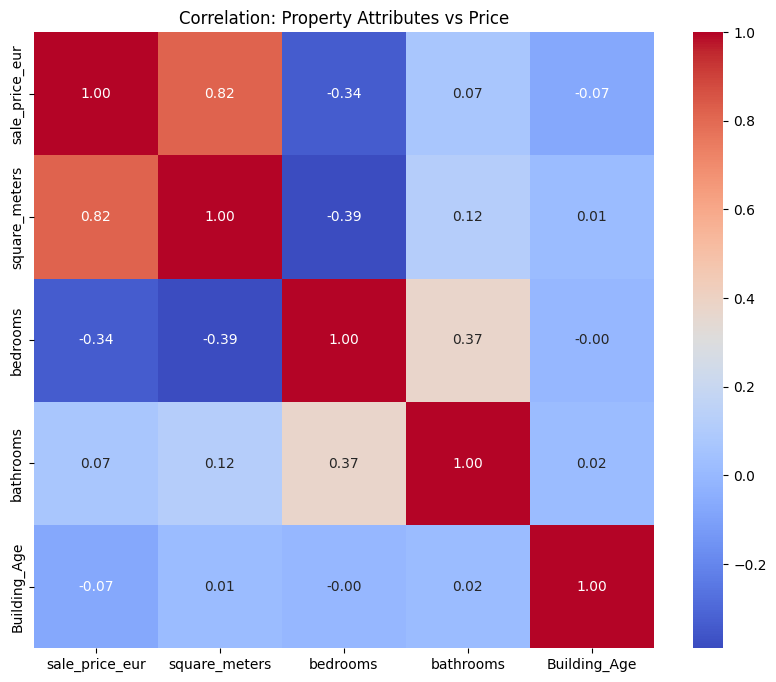

In [7]:

df['Building_Age'] = 2026 - df['year_built']
corr = df[['sale_price_eur', 'square_meters', 'bedrooms', 'bathrooms', 'Building_Age']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation: Property Attributes vs Price')
plt.show()